In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install ultralytics -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if f.endswith(".zip"):
            print(os.path.join(root, f))

Mounted at /content/drive
/content/drive/MyDrive/archive (7).zip
/content/drive/MyDrive/data set crop detection.zip
/content/drive/MyDrive/Copy of train_dataset-20260612T122309Z-3-001.zip
/content/drive/MyDrive/Copy of data set crop detection.zip
/content/drive/MyDrive/clg_proo/train_dataset-20260612T122309Z-3-001.zip
/content/drive/MyDrive/clg_proo/test_dataset-20260612T130851Z-3-001.zip


In [6]:
!unzip -q "/content/drive/MyDrive/clg_proo/train_dataset-20260612T122309Z-3-001.zip" -d /content/

In [7]:
import torch
import os

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Train dataset exists:", os.path.exists("/content/train_dataset"))

CUDA: True
GPU: Tesla T4
Train dataset exists: True


In [8]:
import json
import pandas as pd

with open("/content/train_dataset/gcp_marks.json", "r") as f:
    data = json.load(f)

rows = []

for image_path, label in data.items():

    if "verified_shape" not in label:
        continue

    rows.append({
        "image_path": image_path,
        "x": label["mark"]["x"],
        "y": label["mark"]["y"],
        "shape": label["verified_shape"]
    })

df = pd.DataFrame(rows)

print("Total usable records:", len(df))
df.head()

Total usable records: 996


,image_path,x,y,shape
0,scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_...,3272.769146,1089.329220,Cross
1,RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_...,2991.971596,2445.860741,Cross
2,RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_...,2687.926479,1552.879752,Cross
3,RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_...,2862.995819,792.509426,Cross
4,RDCW-Reddipalayam Limestone Mine/MCDR_ML1_2_3_...,2486.411284,607.232596,Cross


In [9]:
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["shape"].value_counts())

Dataset Shape: (996, 4)

Class Distribution:
shape
L-Shape    491
Square     328
Cross      177
Name: count, dtype: int64


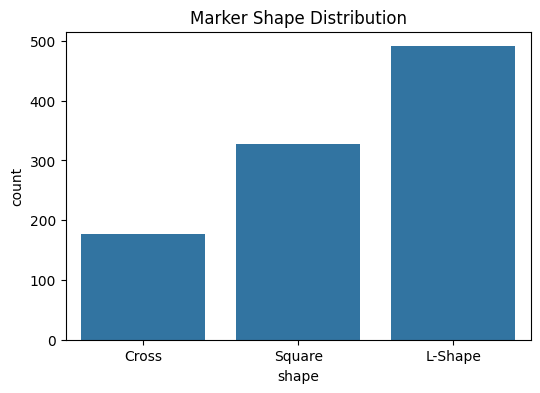

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="shape")
plt.title("Marker Shape Distribution")
plt.show()

In [11]:
import os

root_dir = "/content/train_dataset"

existing_rows = []

for _, row in df.iterrows():

    full_path = os.path.join(
        root_dir,
        row["image_path"]
    )

    if os.path.exists(full_path):
        existing_rows.append(row)

clean_df = pd.DataFrame(existing_rows)

print("Original Records:", len(df))
print("Available Images:", len(clean_df))

Original Records: 996
Available Images: 605


In [12]:
IMG_W = 4096
IMG_H = 2730

bad_rows = clean_df[
    (clean_df["x"] < 0) |
    (clean_df["x"] > IMG_W) |
    (clean_df["y"] < 0) |
    (clean_df["y"] > IMG_H)
]

print("Bad rows:", len(bad_rows))

Bad rows: 19


In [13]:
clean_df_fixed = clean_df.copy()

clean_df_fixed["x"] = clean_df_fixed["x"].clip(0, 4095)
clean_df_fixed["y"] = clean_df_fixed["y"].clip(0, 2729)

print("Coordinates fixed")

Coordinates fixed


In [14]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    clean_df_fixed,
    test_size=0.20,
    random_state=42,
    stratify=clean_df_fixed["shape"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 484
Val: 121


In [15]:
import os

os.makedirs("/content/yolo_dataset/images/train", exist_ok=True)
os.makedirs("/content/yolo_dataset/images/val", exist_ok=True)

os.makedirs("/content/yolo_dataset/labels/train", exist_ok=True)
os.makedirs("/content/yolo_dataset/labels/val", exist_ok=True)

print("Folders created")

Folders created


In [16]:
import os
import shutil

class_map = {
    "Cross": 0,
    "Square": 1,
    "L-Shape": 2
}

IMG_W = 4096
IMG_H = 2730
BOX_SIZE = 80

source_root = "/content/train_dataset"

for split_name, split_df in [
    ("train", train_df),
    ("val", val_df)
]:

    for _, row in split_df.iterrows():

        src_img = os.path.join(source_root, row["image_path"])

        image_name = os.path.basename(row["image_path"])

        dst_img = f"/content/yolo_dataset/images/{split_name}/{image_name}"

        shutil.copy2(src_img, dst_img)

        center_x = row["x"] / IMG_W
        center_y = row["y"] / IMG_H

        box_w = BOX_SIZE / IMG_W
        box_h = BOX_SIZE / IMG_H

        class_id = class_map[row["shape"]]

        label_line = (
            f"{class_id} "
            f"{center_x} "
            f"{center_y} "
            f"{box_w} "
            f"{box_h}"
        )

        label_name = image_name.rsplit(".", 1)[0] + ".txt"

        with open(
            f"/content/yolo_dataset/labels/{split_name}/{label_name}",
            "w"
        ) as f:
            f.write(label_line)

print("YOLO dataset created")

YOLO dataset created


In [17]:
import os

print("Train Images:", len(os.listdir("/content/yolo_dataset/images/train")))
print("Val Images:", len(os.listdir("/content/yolo_dataset/images/val")))

print("Train Labels:", len(os.listdir("/content/yolo_dataset/labels/train")))
print("Val Labels:", len(os.listdir("/content/yolo_dataset/labels/val")))

Train Images: 483
Val Images: 121
Train Labels: 483
Val Labels: 121


In [18]:
print(
    set(train_df["image_path"]).union(set(val_df["image_path"]))
)

{'Egypt-New city/Survey 1/48G65/DJI_20241107101508_0117.JPG', 'Vedanta GOA Bicholim/MCDR 2024/GCP01/1_DJI_0044.JPG', 'Vedanta GOA Bicholim/MCDR 2024/GCP25/24_5_DJI_0019.JPG', 'scout_966/b6b0bde0b9c22f32aba36367/GCP108/DJI_20260206093851_0144_D.JPG', 'Vedanta GOA Bicholim/MCDR 2024/GCP29/23_4_DJI_0867.JPG', 'Vedanta GOA Bicholim/MCDR 2024/GCP12/10_2_DJI_0022.JPG', 'Egypt-New city/Survey 1/12G67/DJI_20241107095814_0009.JPG', 'Seashell Ras el Hekma/Survey 3/GCP18/DJI_20240605112625_0221.JPG', 'Seashell Ras el Hekma/Survey 3/GCP18/DJI_20240605112104_0109.JPG', 'Vedanta GOA Bicholim/MCDR 2024/GCP01/1_DJI_0987.JPG', 'Adani GP-III CG/April_2025/GCP10/DJI_20250502155101_0341_D.JPG', 'Egypt-New city/Survey 1/14G66/DJI_20241107100920_0080.JPG', 'Adani GP-III CG/April_2025/GCP15/DJI_20250503114718_0006_D.JPG', 'scout_966/a7ee1866bbb652c2d0b92546/GCP63/DJI_20260211102505_0121_D.JPG', 'scout_966/b6b0bde0b9c22f32aba36367/GCP89/DJI_20260207114710_0591_D.JPG', 'Vedanta GOA Bicholim/MCDR 2024/GCP29/24_

In [19]:
yaml_content = """
path: /content/yolo_dataset

train: images/train
val: images/val

names:
  0: Cross
  1: Square
  2: L-Shape
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created")

data.yaml created


In [20]:
with open("/content/yolo_dataset/data.yaml", "r") as f:
    print(f.read())


path: /content/yolo_dataset

train: images/train
val: images/val

names:
  0: Cross
  1: Square
  2: L-Shape



In [21]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/yolo_dataset/data.yaml",
    epochs=150,
    imgsz=960,
    batch=8,
    device=0,
    patience=30,
    cache=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5c7d99f470>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [22]:
import shutil

shutil.copy(
    "/content/runs/detect/train/weights/best.pt",
    "/content/drive/MyDrive/best_gcp_detector.pt"
)

print("✅ Model saved successfully")

✅ Model saved successfully


In [23]:
import os

print(os.path.exists("/content/drive/MyDrive/best_gcp_detector.pt"))

True


In [24]:
import shutil

shutil.copytree(
    "/content/runs/detect/train",
    "/content/drive/MyDrive/gcp_training_results",
    dirs_exist_ok=True
)

print("✅ Training results saved")

✅ Training results saved


In [2]:
import os

print(os.path.exists("/content/drive/MyDrive/gcp_training_results"))

True


In [3]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best_gcp_detector.pt")

In [4]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best_gcp_detector.pt")

results = model.predict(
    source="/content/test_dataset",
    imgsz=960,
    conf=0.25,
    save=True
)

FileNotFoundError: No images or videos found in /content/test_dataset. Supported formats are:
images: {'png', 'jp2', 'jpg', 'dng', 'heif', 'bmp', 'tiff', 'jpeg', 'avif', 'jpeg2000', 'heic', 'mpo', 'tif', 'webp'}
videos: {'m4v', 'mpeg', 'avi', 'mkv', 'mp4', 'mpg', 'ts', 'gif', 'mov', 'asf', 'webm', 'wmv'}

In [28]:
!unzip -q "/content/drive/MyDrive/clg_proo/test_dataset-20260612T130851Z-3-001.zip" -d /content/

In [29]:
import os

print(os.path.exists("/content/test_dataset"))

True


In [31]:
import os

for root, dirs, files in os.walk("/content/test_dataset"):
    print("Folder:", root)
    print("Files:", len(files))
    print("Dirs:", len(dirs))
    print("-" * 50)
    if len(files) > 0:
        print("Example file:", files[0])
        break

Folder: /content/test_dataset
Files: 0
Dirs: 73
--------------------------------------------------
Folder: /content/test_dataset/Juniper Gujarat
Files: 0
Dirs: 1
--------------------------------------------------
Folder: /content/test_dataset/Juniper Gujarat/Gujarat20-04-24
Files: 0
Dirs: 1
--------------------------------------------------
Folder: /content/test_dataset/Juniper Gujarat/Gujarat20-04-24/GCP3
Files: 1
Dirs: 0
--------------------------------------------------
Example file: DJI_20240420162131_0074_V.JPG


In [32]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best_gcp_detector.pt")

results = model.predict(
    source="/content/test_dataset/Juniper Gujarat/Gujarat20-04-24/GCP3/DJI_20240420162131_0074_V.JPG",
    imgsz=960,
    conf=0.25,
    save=True
)


image 1/1 /content/test_dataset/Juniper Gujarat/Gujarat20-04-24/GCP3/DJI_20240420162131_0074_V.JPG: 736x960 1 L-Shape, 52.0ms
Speed: 6.9ms preprocess, 52.0ms inference, 4.5ms postprocess per image at shape (1, 3, 736, 960)
Results saved to /content/runs/detect/predict


In [6]:
import os

test_images = []

for root, dirs, files in os.walk("/content/test_dataset"):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            test_images.append(os.path.join(root, f))

print("Total test images:", len(test_images))
print("Example:", test_images[0])

Total test images: 300
Example: /content/test_dataset/Juniper Gujarat/Gujarat20-04-24/GCP3/DJI_20240420162131_0074_V.JPG


In [1]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best_gcp_detector.pt")

model.predict(
    source="/content/test_dataset",
    imgsz=960,
    conf=0.25,
    save=True,
    stream=True
)

<generator object BasePredictor.stream_inference at 0x7a242983b400>

In [ ]:
import os

predict_dir = "/content/runs/detect/predict"

print("Prediction images:", len(os.listdir(predict_dir)))

In [3]:
import os

print(os.path.exists("/content/drive/MyDrive/best_gcp_detector.pt"))

True


In [4]:
import os

print(os.listdir("/content/runs/detect/train"))

['confusion_matrix.png', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'train_batch0.jpg', 'val_batch2_pred.jpg', 'BoxPR_curve.png', 'confusion_matrix_normalized.png', 'results.png', 'val_batch1_pred.jpg', 'BoxP_curve.png', 'args.yaml', 'val_batch2_labels.jpg', 'train_batch2.jpg', 'BoxF1_curve.png', 'weights', 'results.csv', 'BoxR_curve.png', 'val_batch0_labels.jpg', 'train_batch1.jpg', 'labels.jpg']


In [5]:
import os
print(os.listdir("/content/runs/detect/train"))

['confusion_matrix.png', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'train_batch0.jpg', 'val_batch2_pred.jpg', 'BoxPR_curve.png', 'confusion_matrix_normalized.png', 'results.png', 'val_batch1_pred.jpg', 'BoxP_curve.png', 'args.yaml', 'val_batch2_labels.jpg', 'train_batch2.jpg', 'BoxF1_curve.png', 'weights', 'results.csv', 'BoxR_curve.png', 'val_batch0_labels.jpg', 'train_batch1.jpg', 'labels.jpg']


In [6]:
import shutil

shutil.copytree(
    "/content/runs/detect/train",
    "/content/drive/MyDrive/gcp_final_training",
    dirs_exist_ok=True
)

print("✅ Training folder saved")

✅ Training folder saved


In [7]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best_gcp_detector.pt")

results = model.predict(
    source="/content/test_dataset/Juniper Gujarat/Gujarat20-04-24/GCP3/DJI_20240420162131_0074_V.JPG",
    imgsz=960,
    conf=0.25,
    save=True
)


image 1/1 /content/test_dataset/Juniper Gujarat/Gujarat20-04-24/GCP3/DJI_20240420162131_0074_V.JPG: 736x960 1 L-Shape, 48.3ms
Speed: 18.6ms preprocess, 48.3ms inference, 35.0ms postprocess per image at shape (1, 3, 736, 960)
Results saved to /content/runs/detect/predict-2


In [8]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(
    "/content/runs/detect/predict-2/DJI_20240420162131_0074_V.JPG"
)

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

requirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 209ms
Prepared 1 package in 39ms
Installed 1 package in 1ms
 + pi-heif==1.4.0

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/predict-2/DJI_20240420162131_0074_V.JPG'

In [9]:
import os

print(os.listdir("/content/runs/detect"))

['predict-2', 'train', 'predict']


In [10]:
import os

for root, dirs, files in os.walk("/content/runs/detect"):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, f))

/content/runs/detect/predict-2/DJI_20240420162131_0074_V.jpg
/content/runs/detect/train/confusion_matrix.png
/content/runs/detect/train/val_batch0_pred.jpg
/content/runs/detect/train/val_batch1_labels.jpg
/content/runs/detect/train/train_batch0.jpg
/content/runs/detect/train/val_batch2_pred.jpg
/content/runs/detect/train/BoxPR_curve.png
/content/runs/detect/train/confusion_matrix_normalized.png
/content/runs/detect/train/results.png
/content/runs/detect/train/val_batch1_pred.jpg
/content/runs/detect/train/BoxP_curve.png
/content/runs/detect/train/val_batch2_labels.jpg
/content/runs/detect/train/train_batch2.jpg
/content/runs/detect/train/BoxF1_curve.png
/content/runs/detect/train/BoxR_curve.png
/content/runs/detect/train/val_batch0_labels.jpg
/content/runs/detect/train/train_batch1.jpg
/content/runs/detect/train/labels.jpg
/content/runs/detect/predict/DJI_20240420162131_0074_V.jpg


/content/runs/detect/predict-2/DJI_20240420162131_0074_V.jpg


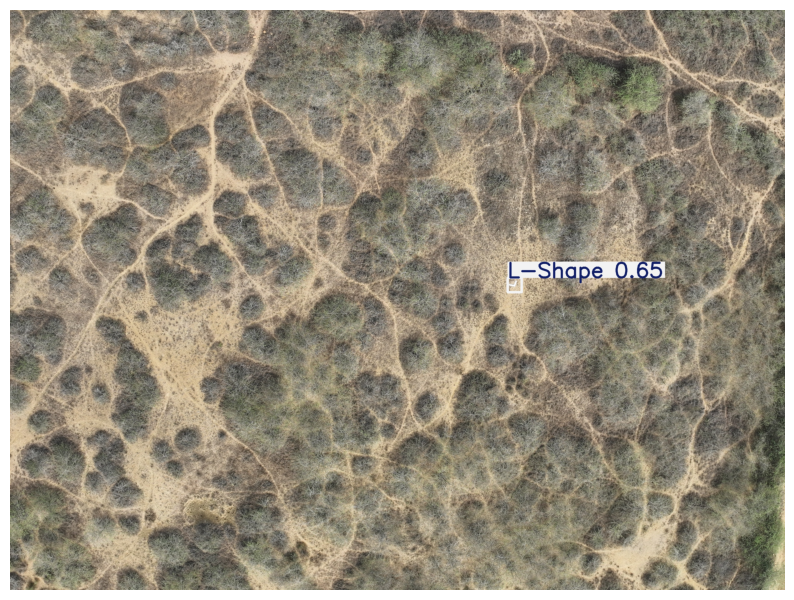

SystemExit: 

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import os

for root, dirs, files in os.walk("/content/runs/detect"):
    for f in files:
        if f.lower().endswith(".jpg"):
            img_path = os.path.join(root, f)
            print(img_path)

            img = Image.open(img_path)
            plt.figure(figsize=(10,8))
            plt.imshow(img)
            plt.axis("off")
            plt.show()

            raise SystemExit

In [12]:
import os

print(os.path.exists("/content/drive/MyDrive/best_gcp_detector.pt"))

True


In [13]:
import os

print(os.path.exists("/content/test_dataset"))

True


In [14]:
import os

test_images = []

for root, dirs, files in os.walk("/content/test_dataset"):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            test_images.append(os.path.join(root, f))

print("Total test images:", len(test_images))

Total test images: 300


In [15]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best_gcp_detector.pt")

print("Model Loaded")

Model Loaded


In [16]:
import json
import os
from tqdm import tqdm

predictions = {}

class_names = {
    0: "Cross",
    1: "Square",
    2: "L-Shape"
}

for img_path in tqdm(test_images):

    results = model.predict(
        source=img_path,
        conf=0.25,
        verbose=False
    )

    relative_path = os.path.relpath(
        img_path,
        "/content/test_dataset"
    )

    if len(results[0].boxes) > 0:

        box = results[0].boxes.xyxy[0].cpu().numpy()

        x1, y1, x2, y2 = box

        center_x = float((x1 + x2) / 2)
        center_y = float((y1 + y2) / 2)

        cls_id = int(
            results[0].boxes.cls[0]
            .cpu()
            .numpy()
        )

        shape = class_names[cls_id]

    else:

        center_x = -1
        center_y = -1
        shape = "Unknown"

    predictions[relative_path] = {
        "mark": {
            "x": center_x,
            "y": center_y
        },
        "verified_shape": shape
    }

with open("predictions.json", "w") as f:
    json.dump(
        predictions,
        f,
        indent=4
    )

print("predictions.json created")

100%|██████████| 300/300 [00:42<00:00,  7.14it/s]

predictions.json created


In [17]:
import json

with open("predictions.json") as f:
    preds = json.load(f)

print("Predictions:", len(preds))

first_key = list(preds.keys())[0]

print(first_key)
print(preds[first_key])

Predictions: 300
Juniper Gujarat/Gujarat20-04-24/GCP3/DJI_20240420162131_0074_V.JPG
{'mark': {'x': 2667.4365234375, 'y': 1457.498291015625}, 'verified_shape': 'L-Shape'}


In [18]:
import shutil

shutil.copy(
    "predictions.json",
    "/content/drive/MyDrive/predictions.json"
)

print("Saved")

Saved


In [19]:
import os
import shutil

# Create submission folder
submission_dir = "/content/drive/MyDrive/Skylark_Assignment"

os.makedirs(submission_dir, exist_ok=True)

# Copy model
shutil.copy(
    "/content/drive/MyDrive/best_gcp_detector.pt",
    f"{submission_dir}/best_gcp_detector.pt"
)

# Copy predictions
shutil.copy(
    "/content/drive/MyDrive/predictions.json",
    f"{submission_dir}/predictions.json"
)

# Copy training results
shutil.copytree(
    "/content/drive/MyDrive/gcp_final_training",
    f"{submission_dir}/training_results",
    dirs_exist_ok=True
)

print("✅ Submission folder created")

✅ Submission folder created
